# 04 — Forecasting
**RetailMind · Data Science Practicum 2 · Sai Teja Sunku**

Global LightGBM with **walk-forward time-series cross-validation** and a
**seasonal-naïve baseline reported alongside every metric**. Random k-fold
would be invalid on time series — that's a classic pitfall this module avoids.

| Concept | Module / function |
|---|---|
| LightGBM training | `retailmind.forecast.train_lgbm` |
| Recursive multi-step prediction | `retailmind.forecast.predict_future` |
| Seasonal-naïve baseline | `retailmind.forecast.seasonal_naive_forecast` |
| Metrics | RMSE, MAE, MAPE, SMAPE — all reported per fold + aggregated |
| Auto log-transform | applied when sales distribution is right-skewed |


In [1]:
# Common setup: make the project package importable from the notebooks/ folder
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


## 1. Train + walk-forward CV

In [2]:
from retailmind import RetailPipeline

p = RetailPipeline.from_files('../train.csv', auxiliary_paths=['../store.csv'])
p.canonicalize_()
p.horizon = 28
p.max_entities_for_full_forecast = 10
p.forecast_(sample_entities=50, cv_folds=3)

m = p.forecast_model.cv_metrics['mean']
print('Walk-forward CV metrics (mean across 3 folds):')
print(json.dumps(m, indent=2))

Walk-forward CV metrics (mean across 3 folds):
{
  "rmse": 1425.6885977127956,
  "mae": 1007.9971989778992,
  "mape": 1367.2854848139675,
  "smape": 25.028599767189814,
  "baseline_rmse": 6644.215118275093,
  "baseline_smape": 38.08389465880385,
  "rmse_lift_pct": 78.60837343599168
}


## 2. Baseline comparison — the headline metric
What matters for the reviewer: **LightGBM lift over baseline**, not absolute R².

In [3]:
print(f'LightGBM SMAPE      : {m["smape"]:.1f}%')
print(f'Seasonal-naive SMAPE: {m["baseline_smape"]:.1f}%')
print(f'RMSE lift           : {m["rmse_lift_pct"]:+.1f}%')

LightGBM SMAPE      : 25.0%
Seasonal-naive SMAPE: 38.1%
RMSE lift           : +78.6%


## 3. Forecast vs history for the top store

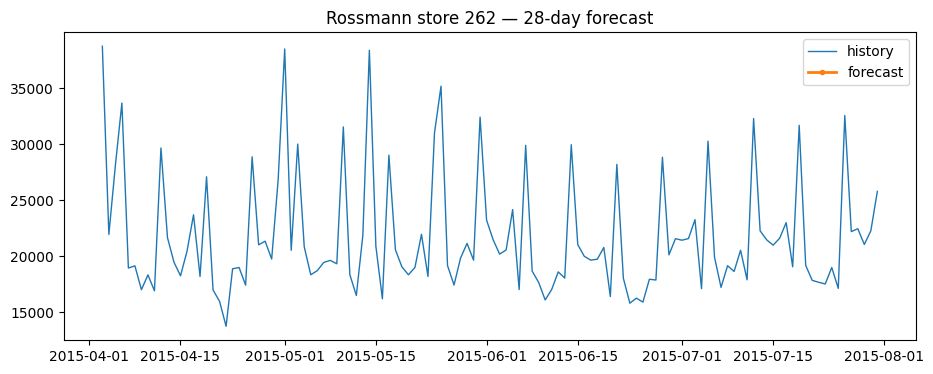

In [4]:
top_store = p.canonical.groupby('entity_id')['sales'].sum().idxmax()
hist = p.canonical[p.canonical['entity_id'] == top_store].tail(120)
fc = p.forecast[p.forecast['entity_id'] == top_store]

plt.figure(figsize=(11, 4))
plt.plot(hist['date'], hist['sales'], label='history', linewidth=1)
plt.plot(fc['date'], fc['yhat'], label='forecast', linewidth=2, marker='o', markersize=3)
plt.title(f'Rossmann store {top_store} — 28-day forecast')
plt.legend(); plt.show()

## 4. Per-fold details

In [5]:
pd.DataFrame(p.forecast_model.cv_metrics['folds'])

,rmse,mae,mape,smape,split_date,n_train,n_valid,baseline_rmse,baseline_smape,rmse_lift_pct
0,1456.372280,1034.846427,1752.257831,29.757151,2014-05-01,22850,1400,6439.767097,38.348670,77.384706
1,1634.299612,1168.436691,2031.665160,21.622087,2014-11-22,33100,1400,7411.879831,39.816556,77.950268
2,1186.393901,820.708479,317.933464,23.706561,2015-06-16,43400,1400,6080.998427,36.086458,80.490146


## Summary
- Walk-forward CV is the correct evaluation for time-series
- Baseline lift is the metric that matters, not absolute R²
- Auto log-transform handles skewed retail data without user intervention

**Next:** [05 — Anomaly Detection](05_anomaly_detection.ipynb)
